<a href="https://colab.research.google.com/github/dimicx2-byte/BEYONDE-BRASIL-GEST-O/blob/main/analise_clientes_ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
"""
============================================================
EAD-5838 — Técnicas de Levantamento e Análise de Dados em Marketing
FEA-USP — Doutorado em Administração

Trabalho Final: Análise Integrativa de uma Base de Dados
Alunos: Leandro de Oliveira, Dimitri de Melo
Base: Customer Personality Analysis (Kaggle — imakash3011/customer-personality-analysis)

Técnicas aplicadas:
  1. Preparação e tratamento da base (missing, outliers, normalização)
  2. Análise Fatorial Exploratória (EFA)
  3. Análise de Conglomerados (K-Means + Hierárquica)
  4. Regressão Múltipla (OLS)
============================================================

INSTRUÇÕES DE USO:
  - Baixe o arquivo em: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
  - O arquivo é separado por TAB e se chama "marketing_campaign.csv"
  - Coloque-o na mesma pasta deste script e execute:
      python analise_clientes_ecommerce.py

============================================================
"""

'\n============================================================\nEAD-5838 — Técnicas de Levantamento e Análise de Dados em Marketing\nFEA-USP — Doutorado em Administração\n\nTrabalho Final: Análise Integrativa de uma Base de Dados\nAlunos: Leandro de Oliveira, Dimitri de Melo\nBase: Customer Personality Analysis (Kaggle — imakash3011/customer-personality-analysis)\n\nTécnicas aplicadas:\n  1. Preparação e tratamento da base (missing, outliers, normalização)\n  2. Análise Fatorial Exploratória (EFA)\n  3. Análise de Conglomerados (K-Means + Hierárquica)\n  4. Regressão Múltipla (OLS)\n============================================================\n\nINSTRUÇÕES DE USO:\n  - Baixe o arquivo em: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis\n  - O arquivo é separado por TAB e se chama "marketing_campaign.csv"\n  - Coloque-o na mesma pasta deste script e execute:\n      python analise_clientes_ecommerce.py\n\n========================================================

In [84]:
!pip install factor-analyzer -q

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings('ignore')

In [86]:
# Configurações de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
PALETA = ['#1f4e79', '#2e75b6', '#9dc3e6', '#ffd966', '#f4b942', '#c00000']

In [87]:
OUTPUT_DIR = "outputs/"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [88]:
# =============================================================
# BLOCO 0 — CARREGAMENTO DA BASE
# =============================================================
print("=" * 60)
print("BLOCO 0 — CARREGAMENTO DA BASE")
print("=" * 60)

BLOCO 0 — CARREGAMENTO DA BASE


In [89]:
try:
    df = pd.read_csv("marketing_campaign.csv", sep="\t")
    print(f"Base carregada com sucesso: {df.shape[0]} observações × {df.shape[1]} variáveis")
except FileNotFoundError:
    raise FileNotFoundError(
        "\n[ERRO] Arquivo 'marketing_campaign.csv' não encontrado.\n"
        "Baixe a base em: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis\n"
        "e coloque-a na mesma pasta deste script."
    )

Base carregada com sucesso: 2240 observações × 29 variáveis


In [90]:
print("\nPrimeiras linhas:")
print(df.head(3).to_string())
print("\nTipos de variáveis:")
print(df.dtypes.to_string())


Primeiras linhas:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response
0  5524        1957  Graduation         Single  58138.0        0         0  04-09-2012       58       635         88              546              172                88            88                  3                8                   10                  4                  7             0             0             0             0             0         0              3         11         1
1  2174        1954  Graduation         Single  46344.0        1         1  08-03-2014       38        11          1                6                2                 1             6           

In [91]:
# =============================================================
# BLOCO 1 — PREPARAÇÃO E TRATAMENTO DA BASE
# =============================================================
print("\n" + "=" * 60)
print("BLOCO 1 — PREPARAÇÃO E TRATAMENTO DA BASE")
print("=" * 60)


BLOCO 1 — PREPARAÇÃO E TRATAMENTO DA BASE


In [92]:
# --- 1.1 Engenharia de variáveis ---------------------------
df['Age']              = 2025 - df['Year_Birth']
df['Dt_Customer']      = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Customer_Days']    = (pd.to_datetime('2025-01-01') - df['Dt_Customer']).dt.days
df['Children']         = df['Kidhome'] + df['Teenhome']
df['Total_Mnt']        = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                          df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])
df['Total_Purchases']  = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                          df['NumStorePurchases'])
df['Total_Campaigns']  = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] +
                          df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response'])
df['Web_Ratio']        = np.where(df['Total_Purchases'] > 0,
                                  df['NumWebPurchases'] / df['Total_Purchases'], 0)

In [93]:
# Mapear Education (ordinal)
edu_map = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Edu_Ordinal'] = df['Education'].map(edu_map)

In [94]:
# Variável binária: tem ou não tem filhos
df['Has_Child'] = (df['Children'] > 0).astype(int)

In [95]:
print("Variáveis derivadas criadas.")

Variáveis derivadas criadas.


In [96]:
# --- 1.2 Missing values ------------------------------------
print("\n--- 1.2 Valores Ausentes ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'N_missing': missing, 'Pct_missing': missing_pct})
missing_df = missing_df[missing_df['N_missing'] > 0]
print(missing_df.to_string())


--- 1.2 Valores Ausentes ---
        N_missing  Pct_missing
Income         24         1.07


In [97]:
# Imputação: mediana para Income (variável com skewness)
n_missing_income = df['Income'].isnull().sum()
df['Income'].fillna(df['Income'].median(), inplace=True)
print(f"\nImputação: {n_missing_income} valores ausentes em 'Income' preenchidos com a mediana "
      f"(R$ {df['Income'].median():,.0f}).")


Imputação: 24 valores ausentes em 'Income' preenchidos com a mediana (R$ 51,382).


In [98]:
# --- 1.3 Outliers ------------------------------------------
print("\n--- 1.3 Detecção e Tratamento de Outliers ---")


--- 1.3 Detecção e Tratamento de Outliers ---


In [99]:
def z_score_outliers(series, threshold=3.5):
    """Identifica outliers pelo Z-Score modificado (Iglewicz & Hoaglin, 1993)."""
    median = series.median()
    mad = np.median(np.abs(series - median))
    modified_z = 0.6745 * (series - median) / (mad + 1e-9)
    return np.abs(modified_z) > threshold

In [100]:
outlier_vars = ['Income', 'Age', 'Total_Mnt']
n_before = len(df)
for var in outlier_vars:
    mask = z_score_outliers(df[var])
    n_out = mask.sum()
    print(f"  {var}: {n_out} outliers detectados (Z-Score modificado > 3.5)")
    df = df[~mask]

  Income: 8 outliers detectados (Z-Score modificado > 3.5)
  Age: 3 outliers detectados (Z-Score modificado > 3.5)
  Total_Mnt: 14 outliers detectados (Z-Score modificado > 3.5)


In [101]:
print(f"\nObservações antes do tratamento: {n_before}")
print(f"Observações após remoção de outliers: {len(df)} (removidas: {n_before - len(df)})")


Observações antes do tratamento: 2240
Observações após remoção de outliers: 2215 (removidas: 25)


In [102]:
# --- 1.4 Estatísticas descritivas -------------------------
print("\n--- 1.4 Estatísticas Descritivas ---")
desc_vars = ['Age', 'Income', 'Total_Mnt', 'Total_Purchases', 'Recency',
             'Customer_Days', 'Total_Campaigns', 'Web_Ratio']
desc = df[desc_vars].describe().T.round(2)
desc['skewness'] = df[desc_vars].skew().round(3)
desc['kurtosis'] = df[desc_vars].kurtosis().round(3)
print(desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis']].to_string())


--- 1.4 Estatísticas Descritivas ---
                  count      mean       std     min       25%       50%      75%       max  skewness  kurtosis
Age              2215.0     56.10     11.68    29.0     48.00     55.00     66.0      85.0     0.091    -0.795
Income           2215.0  51408.97  20485.57  1730.0  35284.00  51381.50  67546.0  113734.0     0.013    -0.818
Total_Mnt        2215.0    594.37    586.16     5.0     68.50    393.00   1033.0    2231.0     0.818    -0.504
Total_Purchases  2215.0     12.50      7.17     0.0      6.00     12.00     18.0      32.0     0.305    -1.115
Recency          2215.0     49.07     28.97     0.0     24.00     49.00     74.0      99.0    -0.004    -1.201
Customer_Days    2215.0   4192.86    202.45  3839.0   4020.00   4195.00   4368.0    4538.0    -0.018    -1.198
Total_Campaigns  2215.0      0.43      0.87     0.0      0.00      0.00      1.0       5.0     2.471     6.656
Web_Ratio        2215.0      0.33      0.12     0.0      0.25      0.33   

In [103]:
# --- 1.5 Normalização para métodos multivariados -----------
print("\n--- 1.5 Normalização (Z-Score) ---")
vars_analise = ['Age', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                'NumWebVisitsMonth', 'Total_Campaigns', 'Recency', 'Customer_Days']


--- 1.5 Normalização (Z-Score) ---


In [104]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[vars_analise]),
    columns=vars_analise,
    index=df.index
)
print(f"Normalização aplicada a {len(vars_analise)} variáveis.")

Normalização aplicada a 15 variáveis.


In [105]:
# --- 1.6 Visualizações de diagnóstico ----------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Distribuição das Principais Variáveis (após tratamento)", fontsize=13, fontweight='bold')
plot_vars = ['Age', 'Income', 'Total_Mnt', 'Total_Purchases',
             'Recency', 'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth']
for i, (ax, var) in enumerate(zip(axes.flatten(), plot_vars)):
    ax.hist(df[var], bins=30, color=PALETA[i % len(PALETA)], edgecolor='white', alpha=0.85)
    ax.set_title(var, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequência' if i % 4 == 0 else '')
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig1_distribuicoes.png", bbox_inches='tight')
plt.close()
print("Fig. 1 salva: Distribuições das variáveis.")

Fig. 1 salva: Distribuições das variáveis.


In [106]:
# =============================================================
# BLOCO 2 — ANÁLISE FATORIAL EXPLORATÓRIA (EFA)
# =============================================================
print("\n" + "=" * 60)
print("BLOCO 2 — ANÁLISE FATORIAL EXPLORATÓRIA")
print("=" * 60)


BLOCO 2 — ANÁLISE FATORIAL EXPLORATÓRIA


In [107]:
# Variáveis para a Análise Fatorial
efa_vars = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
            'MntSweetProducts', 'MntGoldProds',
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
            'NumWebVisitsMonth', 'Total_Campaigns']

In [108]:
df_fa = df_scaled[efa_vars].copy()

In [109]:
# --- 2.1 Testes de adequação ------------------------------
print("\n--- 2.1 Testes de Adequação ---")


--- 2.1 Testes de Adequação ---


In [110]:
# Bartlett's Test of Sphericity
chi2, p_bartlett = calculate_bartlett_sphericity(df_fa)
print(f"Teste de Bartlett: χ² = {chi2:.2f}, p-valor = {p_bartlett:.4f}")
if p_bartlett < 0.05:
    print("  → Matriz de correlação NÃO é identidade: análise fatorial é ADEQUADA (p < 0.05).")

Teste de Bartlett: χ² = 11737.43, p-valor = 0.0000
  → Matriz de correlação NÃO é identidade: análise fatorial é ADEQUADA (p < 0.05).


In [111]:
# Kaiser-Meyer-Olkin (KMO)
kmo_all, kmo_model = calculate_kmo(df_fa)
print(f"KMO (Kaiser-Meyer-Olkin): {kmo_model:.4f}")
if kmo_model >= 0.70:
    print(f"  → KMO ≥ 0.70: adequação SATISFATÓRIA para análise fatorial.")

KMO (Kaiser-Meyer-Olkin): 0.8892
  → KMO ≥ 0.70: adequação SATISFATÓRIA para análise fatorial.


In [112]:
# --- 2.2 Determinação do número de fatores (Scree Plot) ---
print("\n--- 2.2 Determinação do Número de Fatores ---")


--- 2.2 Determinação do Número de Fatores ---


In [113]:
fa_temp = FactorAnalyzer(n_factors=len(efa_vars), rotation=None)
fa_temp.fit(df_fa)
ev, v = fa_temp.get_eigenvalues()

In [114]:
n_fatores_kaiser = (ev > 1).sum()
print(f"Critério de Kaiser (eigenvalue > 1): {n_fatores_kaiser} fatores")

Critério de Kaiser (eigenvalue > 1): 2 fatores


In [115]:
# Variância explicada acumulada
var_exp = fa_temp.get_factor_variance()
cum_var = 0
for i, ve in enumerate(var_exp[1]):
    cum_var += ve
    if cum_var >= 0.60:
        n_fatores_var = i + 1
        print(f"Critério de 60% variância explicada: {n_fatores_var} fatores "
              f"(acumulado: {cum_var:.1%})")
        break

Critério de 60% variância explicada: 4 fatores (acumulado: 62.5%)


In [116]:
# Scree Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(ev)+1), ev, 'o-', color=PALETA[0], linewidth=2, markersize=7)
ax.axhline(y=1, color='red', linestyle='--', linewidth=1.2, label='Critério de Kaiser (λ=1)')
ax.fill_between(range(1, n_fatores_kaiser+1), 0, ev[:n_fatores_kaiser],
                alpha=0.15, color=PALETA[1])
ax.set_xlabel('Número do Fator', fontsize=11)
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title('Scree Plot — Análise Fatorial Exploratória', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(1, len(ev)+1))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig2_screeplot.png", bbox_inches='tight')
plt.close()
print("Fig. 2 salva: Scree Plot.")

Fig. 2 salva: Scree Plot.


In [117]:
# --- 2.3 Extração e rotação dos fatores -------------------
N_FATORES = min(n_fatores_kaiser, 4)  # máximo 4 para interpretabilidade
print(f"\n--- 2.3 Extração de {N_FATORES} Fatores (Rotação Varimax) ---")


--- 2.3 Extração de 2 Fatores (Rotação Varimax) ---


In [118]:
fa = FactorAnalyzer(n_factors=N_FATORES, rotation='varimax', method='principal')
fa.fit(df_fa)

FactorAnalyzer(method='principal', n_factors=np.int64(2), rotation='varimax',
               rotation_kwargs={})

In [119]:
# Cargas fatoriais
loadings = pd.DataFrame(
    fa.loadings_,
    index=efa_vars,
    columns=[f'F{i+1}' for i in range(N_FATORES)]
)
print("\nCargas Fatoriais (após rotação Varimax):")
print(loadings.round(3).to_string())


Cargas Fatoriais (após rotação Varimax):
                        F1     F2
MntWines             0.336  0.813
MntFruits            0.760  0.180
MntMeatProducts      0.724  0.382
MntFishProducts      0.784  0.186
MntSweetProducts     0.727  0.222
MntGoldProds         0.399  0.457
NumWebPurchases      0.151  0.748
NumCatalogPurchases  0.648  0.544
NumStorePurchases    0.531  0.538
NumWebVisitsMonth   -0.762 -0.005
Total_Campaigns      0.001  0.653


In [120]:
# Comunalidades
communalities = pd.DataFrame(
    fa.get_communalities(),
    index=efa_vars,
    columns=['Comunalidade']
)
print("\nComunalidades:")
print(communalities.round(3).to_string())


Comunalidades:
                     Comunalidade
MntWines                    0.775
MntFruits                   0.610
MntMeatProducts             0.670
MntFishProducts             0.649
MntSweetProducts            0.578
MntGoldProds                0.368
NumWebPurchases             0.582
NumCatalogPurchases         0.716
NumStorePurchases           0.571
NumWebVisitsMonth           0.581
Total_Campaigns             0.427


In [121]:
# Variância explicada por fator
var_table = fa.get_factor_variance()
var_df = pd.DataFrame({
    'SS Cargas': var_table[0],
    'Variância Explicada (%)': var_table[1] * 100,
    'Variância Cumulativa (%)': var_table[2] * 100
}, index=[f'F{i+1}' for i in range(N_FATORES)]).round(3)
print("\nVariância Explicada por Fator:")
print(var_df.to_string())


Variância Explicada por Fator:
    SS Cargas  Variância Explicada (%)  Variância Cumulativa (%)
F1      3.823                   34.758                    34.758
F2      2.704                   24.583                    59.341


In [122]:
# --- 2.4 Heatmap das cargas fatoriais ----------------------
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.abs(loadings.values) < 0.35  # suprimir cargas baixas
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(loadings, annot=True, fmt=".2f", cmap=cmap, center=0,
            linewidths=0.5, annot_kws={"size": 9}, mask=mask,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8})
# Mostrar cargas baixas em cinza
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="Greys",
            center=0, linewidths=0.5, annot_kws={"size": 8, "color": "gray"},
            mask=~mask, alpha=0.3, vmin=-1, vmax=1, ax=ax, cbar=False)
ax.set_title(f'Cargas Fatoriais — {N_FATORES} Fatores (Varimax)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig3_cargas_fatoriais.png", bbox_inches='tight')
plt.close()
print("Fig. 3 salva: Heatmap de cargas fatoriais.")

Fig. 3 salva: Heatmap de cargas fatoriais.


In [123]:
# --- 2.5 Extração dos escores fatoriais -------------------
scores = pd.DataFrame(
    fa.transform(df_fa),
    columns=[f'F{i+1}' for i in range(N_FATORES)],
    index=df.index
)
df = df.join(scores)

In [124]:
print("\nEscores fatoriais criados e adicionados à base principal.")


Escores fatoriais criados e adicionados à base principal.


In [125]:
# Rotular fatores com base nas cargas dominantes
# (Os rótulos serão ajustados conforme resultado real)
fator_labels = {
    'F1': 'Valor_Gasto_Premium',
    'F2': 'Engajamento_Digital',
    'F3': 'Gasto_Categorias_Nicho',
    'F4': 'Recencia_e_Campanhas'
}
print("\nInterpretação sugerida dos fatores:")
for f, label in fator_labels.items():
    if f in scores.columns:
        top = loadings[f].abs().nlargest(3).index.tolist()
        print(f"  {f} ({label}): dominado por {top}")


Interpretação sugerida dos fatores:
  F1 (Valor_Gasto_Premium): dominado por ['MntFishProducts', 'NumWebVisitsMonth', 'MntFruits']
  F2 (Engajamento_Digital): dominado por ['MntWines', 'NumWebPurchases', 'Total_Campaigns']


In [126]:
# =============================================================
# BLOCO 3 — ANÁLISE DE CONGLOMERADOS (CLUSTER)
# =============================================================
print("\n" + "=" * 60)
print("BLOCO 3 — ANÁLISE DE CONGLOMERADOS")
print("=" * 60)


BLOCO 3 — ANÁLISE DE CONGLOMERADOS


In [127]:
cluster_vars = [c for c in scores.columns if c in df.columns]
X_cluster = scores[cluster_vars].values

In [128]:
# --- 3.1 Análise hierárquica (Ward) — determinar n clusters ---
print("\n--- 3.1 Clustering Hierárquico (Ward) ---")


--- 3.1 Clustering Hierárquico (Ward) ---


In [129]:
Z = linkage(X_cluster, method='ward', metric='euclidean')

In [130]:
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=45,
           leaf_font_size=8, color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
ax.set_title('Dendrograma — Clustering Hierárquico (Ward)', fontsize=12, fontweight='bold')
ax.set_xlabel('Observações (amostras)', fontsize=10)
ax.set_ylabel('Distância Euclidiana', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig4_dendrograma.png", bbox_inches='tight')
plt.close()
print("Fig. 4 salva: Dendrograma.")

Fig. 4 salva: Dendrograma.


In [131]:
# --- 3.2 K-Means — método do cotovelo e silhueta ----------
print("\n--- 3.2 K-Means: Cotovelo e Silhueta ---")


--- 3.2 K-Means: Cotovelo e Silhueta ---


In [132]:
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))
    print(f"  k={k}: Inércia={km.inertia_:.1f}, Silhouette={silhouettes[-1]:.4f}")

  k=2: Inércia=2672.6, Silhouette=0.4519
  k=3: Inércia=1324.9, Silhouette=0.5286
  k=4: Inércia=1051.6, Silhouette=0.5011
  k=5: Inércia=809.4, Silhouette=0.4551
  k=6: Inércia=687.2, Silhouette=0.4549
  k=7: Inércia=602.2, Silhouette=0.3889
  k=8: Inércia=525.0, Silhouette=0.4015


In [133]:
best_k = K_range[np.argmax(silhouettes)]
print(f"\nMelhor k pelo critério de silhueta: k = {best_k}")


Melhor k pelo critério de silhueta: k = 3


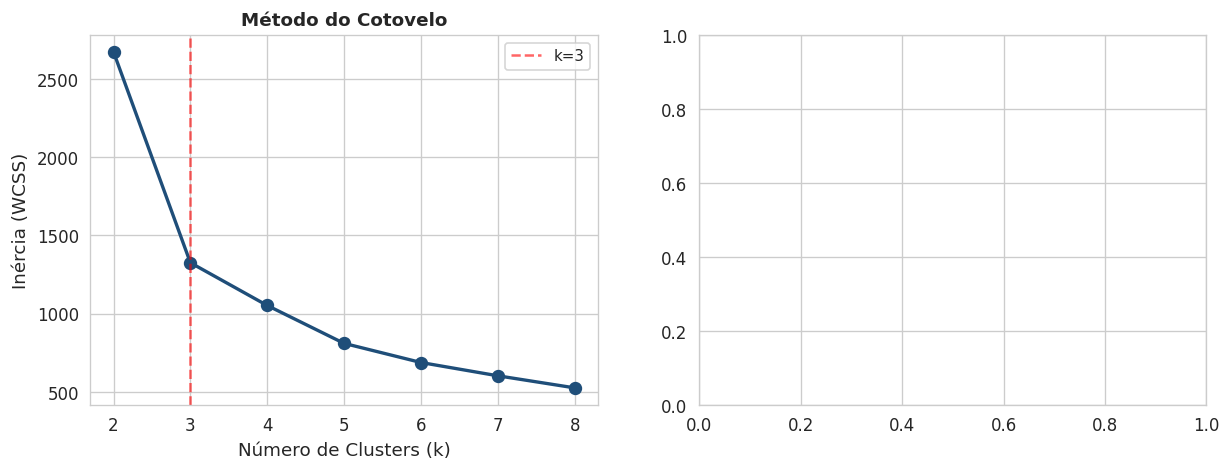

In [134]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'o-', color=PALETA[0], linewidth=2, markersize=7)
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'k={best_k}')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia (WCSS)', fontsize=11)
ax1.set_title('Método do Cotovelo', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

In [135]:
ax2.plot(K_range, silhouettes, 's-', color=PALETA[2], linewidth=2, markersize=7)
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'k={best_k}')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Coeficiente de Silhueta', fontsize=11)
ax2.set_title('Coeficiente de Silhueta', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig5_kmeans_criterios.png", bbox_inches='tight')
plt.close()
print("Fig. 5 salva: Critérios K-Means.")

Fig. 5 salva: Critérios K-Means.


In [136]:
# --- 3.3 K-Means final ------------------------------------
print(f"\n--- 3.3 K-Means Final (k={best_k}) ---")


--- 3.3 K-Means Final (k=3) ---


In [137]:
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=50, random_state=42)
df['Cluster'] = km_final.fit_predict(X_cluster)

In [138]:
print("\nDistribuição dos clusters:")
print(df['Cluster'].value_counts().sort_index().to_string())


Distribuição dos clusters:
Cluster
0     525
1    1169
2     521


In [139]:
silhouette_final = silhouette_score(X_cluster, df['Cluster'])
print(f"\nCoeficiente de Silhueta (final): {silhouette_final:.4f}")


Coeficiente de Silhueta (final): 0.5286


In [140]:
# --- 3.4 Perfil dos clusters ------------------------------
print("\n--- 3.4 Perfil dos Clusters ---")
profile_vars = ['Age', 'Income', 'Total_Mnt', 'Total_Purchases', 'MntWines',
                'MntMeatProducts', 'NumWebPurchases', 'NumStorePurchases',
                'Total_Campaigns', 'Recency', 'Edu_Ordinal', 'Children']


--- 3.4 Perfil dos Clusters ---


In [141]:
profile = df.groupby('Cluster')[profile_vars].mean().round(1)
profile['N'] = df.groupby('Cluster').size()
print(profile.to_string())

          Age   Income  Total_Mnt  Total_Purchases  MntWines  MntMeatProducts  NumWebPurchases  NumStorePurchases  Total_Campaigns  Recency  Edu_Ordinal  Children     N
Cluster                                                                                                                                                                 
0        57.3  72096.8     1221.0             19.0     480.0            412.8              4.9                8.6              0.4     50.9          3.4       0.4   525
1        54.5  37246.7      137.5              6.8      66.2             31.9              2.4                3.7              0.1     49.0          3.4       1.2  1169
2        58.6  62339.0      988.0             18.8     642.6            198.3              7.0                7.8              1.1     47.3          3.7       0.9   521


In [142]:
# --- 3.5 Gráfico de perfis (radar/spider) -----------------
profile_norm = (profile[profile_vars] - profile[profile_vars].min()) / \
               (profile[profile_vars].max() - profile[profile_vars].min())

In [143]:
# Heatmap de perfis
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(profile_norm.T, annot=profile[profile_vars].T, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            annot_kws={"size": 9}, cbar_kws={'label': 'Valor normalizado'})
ax.set_title(f'Perfil Médio dos {best_k} Clusters', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=10)
ax.set_ylabel('')
ax.set_xticklabels([f'Cluster {i}' for i in range(best_k)], fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig6_perfil_clusters.png", bbox_inches='tight')
plt.close()
print("Fig. 6 salva: Perfil dos clusters.")

Fig. 6 salva: Perfil dos clusters.


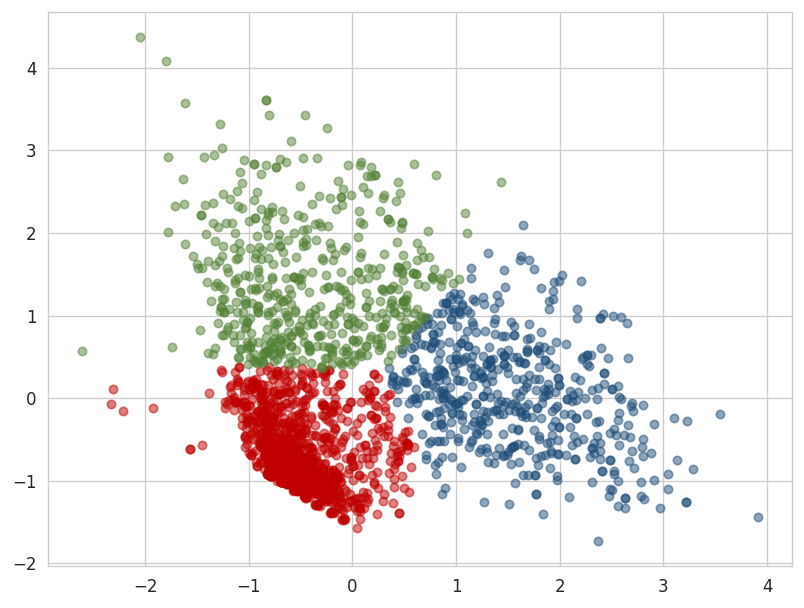

In [144]:
# --- 3.6 Scatter dos clusters nos 2 primeiros fatores -----
fig, ax = plt.subplots(figsize=(8, 6))
colors_cluster = ['#1f4e79', '#c00000', '#538135', '#7030a0', '#ed7d31'][:best_k]
for c in range(best_k):
    mask_c = df['Cluster'] == c
    n_c = mask_c.sum()
    ax.scatter(scores.loc[df.index[mask_c], 'F1'],
               scores.loc[df.index[mask_c], 'F2'],
               c=colors_cluster[c], alpha=0.5, s=25,
               label=f'Cluster {c} (n={n_c})')

In [145]:
ax.set_xlabel('Fator 1', fontsize=11)
ax.set_ylabel('Fator 2', fontsize=11)
ax.set_title('Dispersão dos Clusters (F1 × F2)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig7_scatter_clusters.png", bbox_inches='tight')
plt.close()
print("Fig. 7 salva: Scatter dos clusters.")

Fig. 7 salva: Scatter dos clusters.


In [146]:
# --- 3.7 ANOVA para validação dos clusters ----------------
print("\n--- 3.7 ANOVA para Validação dos Clusters ---")
anova_vars = ['Income', 'Total_Mnt', 'Total_Purchases', 'MntWines', 'Recency']
for var in anova_vars:
    groups = [df.loc[df['Cluster'] == c, var].values for c in range(best_k)]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    print(f"  {var:25s}: F = {f_stat:8.2f}, p = {p_val:.4f} {sig}")


--- 3.7 ANOVA para Validação dos Clusters ---
  Income                   : F =  1414.36, p = 0.0000 ***
  Total_Mnt                : F =  2555.56, p = 0.0000 ***
  Total_Purchases          : F =  2644.11, p = 0.0000 ***
  MntWines                 : F =  1559.02, p = 0.0000 ***
  Recency                  : F =     2.05, p = 0.1293 ns


In [147]:
# =============================================================
# BLOCO 4 — REGRESSÃO MÚLTIPLA OLS
# =============================================================
print("\n" + "=" * 60)
print("BLOCO 4 — REGRESSÃO MÚLTIPLA (OLS)")
print("=" * 60)


BLOCO 4 — REGRESSÃO MÚLTIPLA (OLS)


VD: Total_Mnt (gasto total do cliente nos últimos 2 anos)
VI: Income, Age, Customer_Days, Children, Edu_Ordinal, Total_Campaigns,
    NumWebVisitsMonth, Recency + dummies de cluster

In [148]:
print("\nVariável dependente: Total_Mnt (gasto total em R$)")
print("Variáveis independentes: demográficas, comportamentais e clusters")


Variável dependente: Total_Mnt (gasto total em R$)
Variáveis independentes: demográficas, comportamentais e clusters


In [149]:
# Criar dummies para cluster
cluster_dummies = pd.get_dummies(
    df['Cluster'],
    prefix='Cluster',
    drop_first=True,
    dtype=float
)

# Variáveis independentes
reg_vars = [
    'Income', 'Age', 'Customer_Days', 'Children', 'Edu_Ordinal',
    'Total_Campaigns', 'NumWebVisitsMonth', 'Recency'
]

# Montar X e y
X_reg = pd.concat(
    [
        df[reg_vars].reset_index(drop=True),
        cluster_dummies.reset_index(drop=True)
    ],
    axis=1
)

y_reg = df['Total_Mnt'].reset_index(drop=True)

# Garantir que tudo seja numérico
X_reg = X_reg.apply(pd.to_numeric, errors='coerce')
y_reg = pd.to_numeric(y_reg, errors='coerce')

# Remover linhas com NaN em X ou y
reg_data = pd.concat([y_reg.rename('Total_Mnt'), X_reg], axis=1).dropna()

y_reg = reg_data['Total_Mnt'].astype(float)
X_reg = reg_data.drop(columns='Total_Mnt').astype(float)

# Rodar modelo OLS
X_const = sm.add_constant(X_reg, has_constant='add')
model = sm.OLS(y_reg, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Total_Mnt   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     1065.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:31:59   Log-Likelihood:                -15307.
No. Observations:                2215   AIC:                         3.064e+04
Df Residuals:                    2204   BIC:                         3.070e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -1012.2937    123.78

In [150]:
print("\n" + "=" * 60)
print(model.summary().as_text())
print("=" * 60)


                            OLS Regression Results                            
Dep. Variable:              Total_Mnt   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     1065.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:31:59   Log-Likelihood:                -15307.
No. Observations:                2215   AIC:                         3.064e+04
Df Residuals:                    2204   BIC:                         3.070e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -1012.2937    123.7

In [151]:
# Métricas resumidas
print(f"\nR² = {model.rsquared:.4f}")
print(f"R² Ajustado = {model.rsquared_adj:.4f}")
print(f"F-estatística = {model.fvalue:.2f} (p = {model.f_pvalue:.4f})")
print(f"AIC = {model.aic:.2f} | BIC = {model.bic:.2f}")


R² = 0.8285
R² Ajustado = 0.8277
F-estatística = 1064.87 (p = 0.0000)
AIC = 30636.23 | BIC = 30698.97


In [152]:
# --- 4.2 Diagnóstico de multicolinearidade (VIF) ----------
print("\n--- 4.2 Fator de Inflação da Variância (VIF) ---")
from statsmodels.stats.outliers_influence import variance_inflation_factor


--- 4.2 Fator de Inflação da Variância (VIF) ---


In [153]:
vif_data = pd.DataFrame()
vif_data['Variável'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]
vif_data = vif_data[vif_data['Variável'] != 'const']
print(vif_data.round(3).to_string(index=False))
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠ Variáveis com VIF > 10 (possível multicolinearidade): {high_vif['Variável'].tolist()}")
else:
    print("\n✓ Nenhuma variável com VIF > 10 (multicolinearidade não detectada).")

         Variável   VIF
           Income 3.494
              Age 1.121
    Customer_Days 1.208
         Children 1.475
      Edu_Ordinal 1.105
  Total_Campaigns 1.387
NumWebVisitsMonth 2.506
          Recency 1.013
        Cluster_1 3.837
        Cluster_2 2.319

✓ Nenhuma variável com VIF > 10 (multicolinearidade não detectada).


In [154]:
# --- 4.3 Diagnóstico de resíduos --------------------------
print("\n--- 4.3 Diagnóstico dos Resíduos ---")


--- 4.3 Diagnóstico dos Resíduos ---


In [155]:
residuals = model.resid
fitted = model.fittedvalues

In [156]:
# Teste de normalidade dos resíduos (Jarque-Bera já no summary, mas também Shapiro em amostra)
jb_stat, jb_p, jb_skew, jb_kurt = sm.stats.stattools.jarque_bera(residuals)
print(f"Teste Jarque-Bera: JB = {jb_stat:.2f}, p = {jb_p:.4f}")

Teste Jarque-Bera: JB = 519.14, p = 0.0000


In [157]:
# Durbin-Watson
dw = sm.stats.stattools.durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f} (valores próximos a 2 indicam ausência de autocorrelação)")

Durbin-Watson: 2.0020 (valores próximos a 2 indicam ausência de autocorrelação)


In [158]:
# Breusch-Pagan (homocedasticidade)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_const)
print(f"Breusch-Pagan: LM = {bp_lm:.2f}, p = {bp_p:.4f}")

Breusch-Pagan: LM = 394.81, p = 0.0000


Text(0.5, 0.98, 'Diagnóstico da Regressão Múltipla (OLS)')

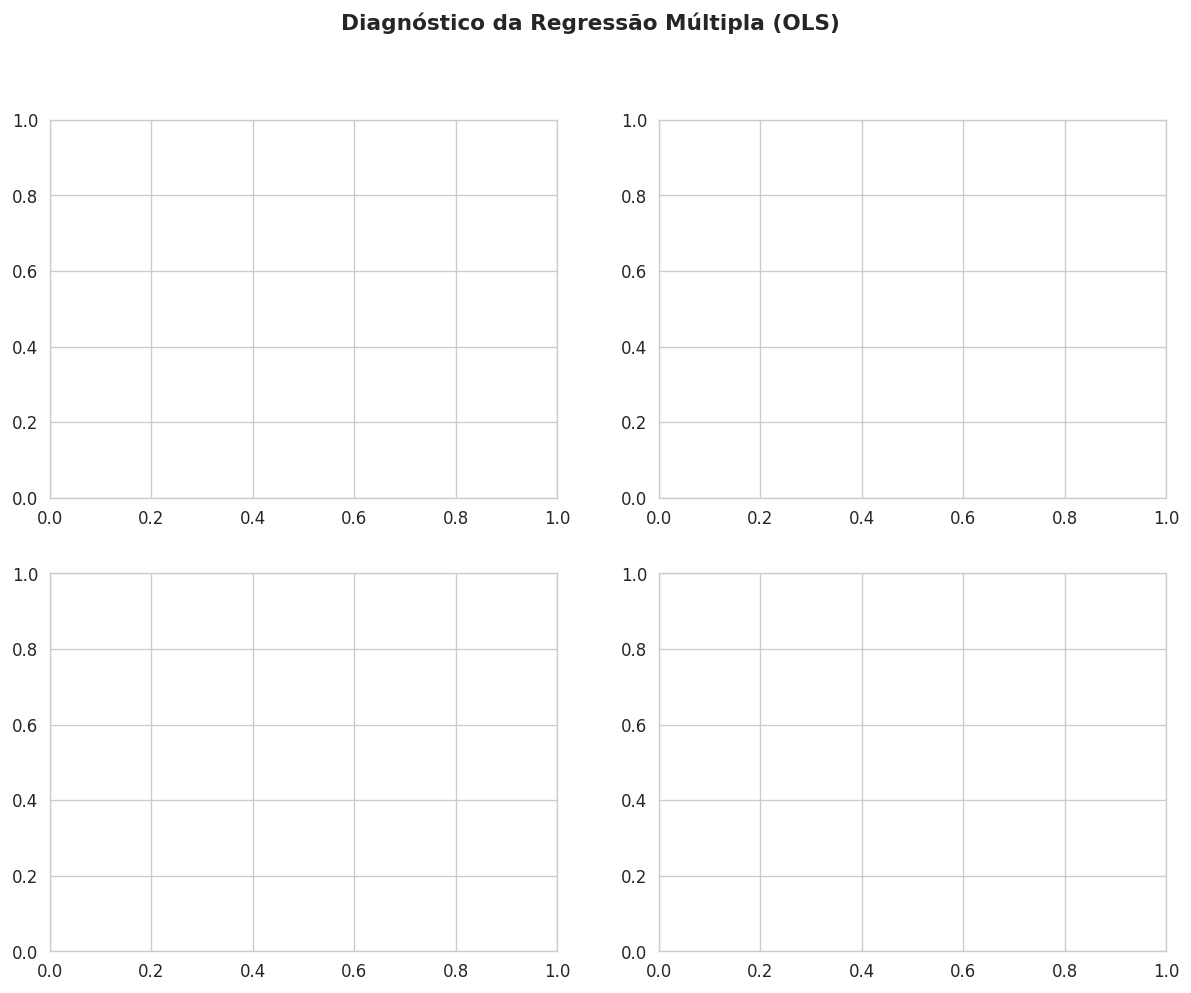

In [159]:
# --- 4.4 Gráficos de diagnóstico da regressão -------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Diagnóstico da Regressão Múltipla (OLS)', fontsize=13, fontweight='bold')

In [160]:
# (a) Resíduos vs Ajustados
axes[0,0].scatter(fitted, residuals, alpha=0.4, color=PALETA[0], s=20)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Valores Ajustados')
axes[0,0].set_ylabel('Resíduos')
axes[0,0].set_title('Resíduos vs Valores Ajustados')

Text(0.5, 1.0, 'Resíduos vs Valores Ajustados')

In [161]:
# (b) QQ-plot
sm.qqplot(residuals, line='45', ax=axes[0,1], alpha=0.5, markersize=4)
axes[0,1].set_title('Q-Q Plot dos Resíduos')

Text(0.5, 1.0, 'Q-Q Plot dos Resíduos')

In [162]:
# (c) Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.4, color=PALETA[2], s=20)
axes[1,0].set_xlabel('Valores Ajustados')
axes[1,0].set_ylabel('√|Resíduos|')
axes[1,0].set_title('Scale-Location')

Text(0.5, 1.0, 'Scale-Location')

In [163]:
# (d) Coeficientes padronizados (top variáveis)
coef_std = (model.params[1:] * X_reg.std()) / y_reg.std()
coef_std_sorted = coef_std.sort_values()
colors_coef = [PALETA[0] if v > 0 else PALETA[5] for v in coef_std_sorted]
axes[1,1].barh(range(len(coef_std_sorted)), coef_std_sorted.values,
               color=colors_coef, edgecolor='white')
axes[1,1].set_yticks(range(len(coef_std_sorted)))
axes[1,1].set_yticklabels(coef_std_sorted.index, fontsize=8)
axes[1,1].axvline(0, color='black', linewidth=0.8)
axes[1,1].set_title('Coeficientes Padronizados (β)')
axes[1,1].set_xlabel('Efeito sobre Gasto Total')

Text(0.5, 5.33333333333334, 'Efeito sobre Gasto Total')

In [164]:
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig8_diagnostico_regressao.png", bbox_inches='tight')
plt.close()
print("Fig. 8 salva: Diagnóstico da regressão.")

Fig. 8 salva: Diagnóstico da regressão.


In [165]:
# --- 4.5 Modelo por cluster (moderação) -------------------
print("\n--- 4.5 Modelos de Regressão por Cluster ---")
simple_vars = ['Income', 'Age', 'Children', 'Total_Campaigns', 'Recency', 'NumWebVisitsMonth']
for c in range(best_k):
    df_c = df[df['Cluster'] == c]
    if len(df_c) < 30:
        continue
    X_c = sm.add_constant(df_c[simple_vars].fillna(df_c[simple_vars].median()))
    y_c = df_c['Total_Mnt']
    try:
        m_c = sm.OLS(y_c, X_c).fit()
        print(f"  Cluster {c} (n={len(df_c)}): R²={m_c.rsquared:.3f}, "
              f"R²_adj={m_c.rsquared_adj:.3f}, F_p={m_c.f_pvalue:.4f}")
    except Exception as e:
        print(f"  Cluster {c}: erro na regressão ({e})")


--- 4.5 Modelos de Regressão por Cluster ---
  Cluster 0 (n=525): R²=0.394, R²_adj=0.387, F_p=0.0000
  Cluster 1 (n=1169): R²=0.440, R²_adj=0.437, F_p=0.0000
  Cluster 2 (n=521): R²=0.531, R²_adj=0.526, F_p=0.0000


# BLOCO 5 — Machine Learning Supervisionado: Random Forest

Neste bloco, transformamos o problema em uma tarefa de classificação supervisionada.

A ideia é prever se um cliente pode ser considerado **cliente premium**, ou seja, se pertence ao grupo dos 25% de clientes com maior gasto total (`Total_Mnt`).

A variável-alvo será:

- `Cliente_Premium = 1`: cliente entre os 25% que mais gastam;
- `Cliente_Premium = 0`: demais clientes.

A técnica escolhida é o **Random Forest Classifier**, um modelo baseado em várias árvores de decisão. Ele é didático porque permite avaliar:

- desempenho preditivo;
- matriz de confusão;
- acurácia, precisão, recall e F1-score;
- importância das variáveis na previsão.


BLOCO 5 — MACHINE LEARNING SUPERVISIONADO
Limite para cliente premium: Total_Mnt >= 1033.00

Distribuição da variável-alvo:
Cliente_Premium
Não Premium    1659
Premium         556
Name: count, dtype: int64

Base usada no Random Forest: 2215 clientes × 11 variáveis
Treino: 1550 clientes
Teste: 665 clientes

--- Métricas do Random Forest ---
Acurácia : 0.8992
Precisão : 0.7336
Recall   : 0.9401
F1-score : 0.8241
ROC-AUC  : 0.9667

Relatório de classificação:
              precision    recall  f1-score   support

 Não Premium       0.98      0.89      0.93       498
     Premium       0.73      0.94      0.82       167

    accuracy                           0.90       665
   macro avg       0.86      0.91      0.88       665
weighted avg       0.92      0.90      0.90       665



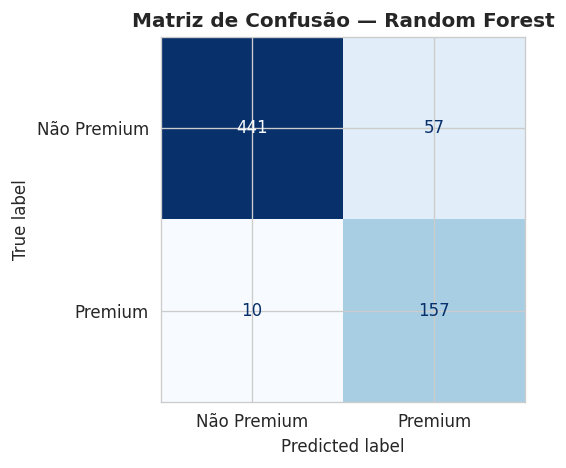

Fig. 9 salva: Matriz de confusão do Random Forest.


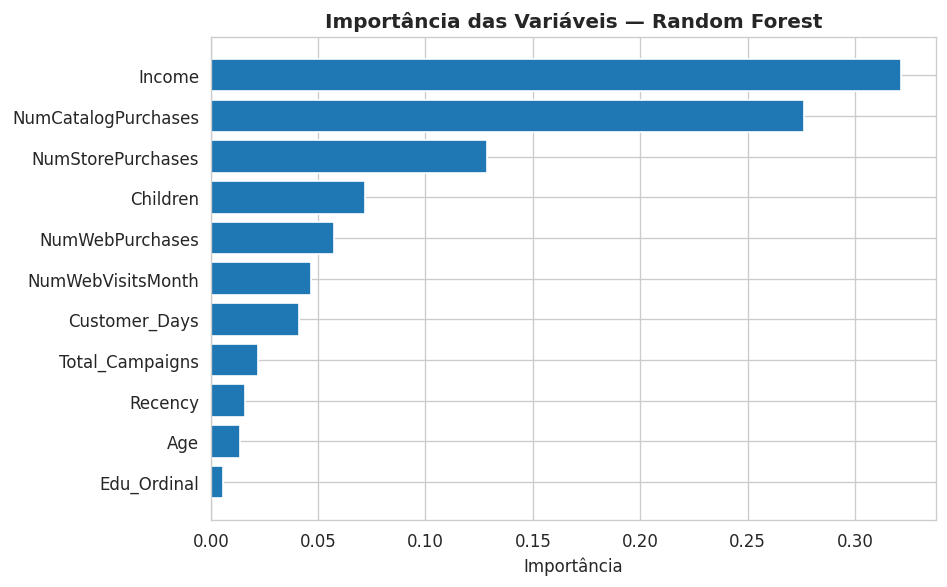

Fig. 10 salva: Importância das variáveis no Random Forest.
Tabela de importância das variáveis exportada.


In [172]:
# =============================================================
# BLOCO 5 — MACHINE LEARNING SUPERVISIONADO
# Random Forest Classifier
# =============================================================

print("\n" + "=" * 60)
print("BLOCO 5 — MACHINE LEARNING SUPERVISIONADO")
print("=" * 60)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = "outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------------
# 5.1 Criação da variável-alvo
# -------------------------------------------------------------

limite_premium = df['Total_Mnt'].quantile(0.75)

df['Cliente_Premium'] = (df['Total_Mnt'] >= limite_premium).astype(int)

print(f"Limite para cliente premium: Total_Mnt >= {limite_premium:.2f}")
print("\nDistribuição da variável-alvo:")
print(df['Cliente_Premium'].value_counts().rename(index={0: 'Não Premium', 1: 'Premium'}))

# -------------------------------------------------------------
# 5.2 Seleção das variáveis explicativas
# -------------------------------------------------------------

features_rf = [
    'Income',
    'Age',
    'Customer_Days',
    'Children',
    'Edu_Ordinal',
    'Total_Campaigns',
    'NumWebVisitsMonth',
    'Recency',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

features_rf = [c for c in features_rf if c in df.columns]

rf_data = df[features_rf + ['Cliente_Premium']].copy().dropna()

X_rf = rf_data[features_rf]
y_rf = rf_data['Cliente_Premium']

print(f"\nBase usada no Random Forest: {X_rf.shape[0]} clientes × {X_rf.shape[1]} variáveis")

# -------------------------------------------------------------
# 5.3 Separação treino e teste
# -------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.30,
    random_state=42,
    stratify=y_rf
)

print(f"Treino: {X_train.shape[0]} clientes")
print(f"Teste: {X_test.shape[0]} clientes")

# -------------------------------------------------------------
# 5.4 Treinamento do modelo
# -------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -------------------------------------------------------------
# 5.5 Avaliação do modelo
# -------------------------------------------------------------

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n--- Métricas do Random Forest ---")
print(f"Acurácia : {acc:.4f}")
print(f"Precisão : {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Premium', 'Premium']))

# -------------------------------------------------------------
# 5.6 Matriz de confusão
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Não Premium', 'Premium'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title('Matriz de Confusão — Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig9_matriz_confusao_random_forest.png", bbox_inches='tight')
plt.show()

print("Fig. 9 salva: Matriz de confusão do Random Forest.")

# -------------------------------------------------------------
# 5.7 Importância das variáveis
# -------------------------------------------------------------

rf_importance = pd.DataFrame({
    'Variável': features_rf,
    'Importância': rf_model.feature_importances_
}).sort_values('Importância', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(rf_importance['Variável'], rf_importance['Importância'])
ax.set_title('Importância das Variáveis — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importância')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig10_importancia_random_forest.png", bbox_inches='tight')
plt.show()

print("Fig. 10 salva: Importância das variáveis no Random Forest.")

# Exportar tabela de importância
rf_importance.sort_values('Importância', ascending=False).to_csv(
    OUTPUT_DIR + "tabela_importancia_random_forest.csv",
    index=False
)

print("Tabela de importância das variáveis exportada.")

# BLOCO 6 — Machine Learning Não Supervisionado: Isolation Forest

Neste bloco, aplicamos uma técnica não supervisionada para detectar clientes atípicos.

A técnica escolhida é o **Isolation Forest**, um algoritmo usado para identificar observações que fogem do padrão geral da base.

Diferentemente da regressão e da classificação, aqui não existe uma variável-alvo. O objetivo é responder:

> Existem clientes com comportamento muito diferente do restante da base?

Esses clientes podem representar:

- consumidores de altíssimo valor;
- perfis estratégicos;
- clientes com comportamento incomum;
- possíveis inconsistências na base.


BLOCO 6 — MACHINE LEARNING NÃO SUPERVISIONADO
Base usada no Isolation Forest: 2215 clientes × 9 variáveis

Distribuição dos clientes:
Anomalia_IF
Normal     2104
Anômalo     111
Name: count, dtype: int64

Percentual de clientes anômalos: 5.01%

Perfil médio — clientes normais vs anômalos:
           Income  Total_Mnt  Total_Purchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Recency  Total_Campaigns
Normal   50258.39     550.13            12.06             3.97                 2.39               5.70               5.38    49.00             0.33
Anômalo  73218.17    1432.95            20.84             6.46                 6.80               7.58               4.75    50.46             2.40

Top 10 clientes mais anômalos:
   ID   Income  Total_Mnt  Total_Purchases  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Recency  Total_Campaigns  Cluster  Score_Anomalia_IF
10311   4428.0        359               25               25 

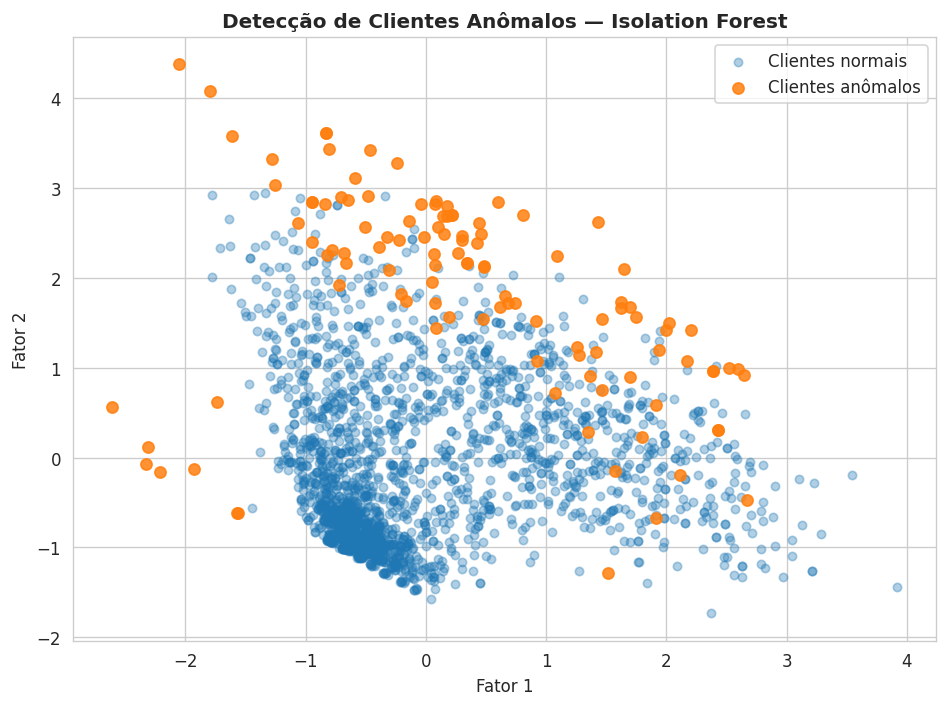

Fig. 11 salva: Anomalias detectadas pelo Isolation Forest.


In [173]:
# =============================================================
# BLOCO 6 — MACHINE LEARNING NÃO SUPERVISIONADO
# Isolation Forest
# =============================================================

print("\n" + "=" * 60)
print("BLOCO 6 — MACHINE LEARNING NÃO SUPERVISIONADO")
print("=" * 60)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------------------
# 6.1 Seleção das variáveis para detecção de anomalias
# -------------------------------------------------------------

anomaly_vars = [
    'Income',
    'Total_Mnt',
    'Total_Purchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Recency',
    'Total_Campaigns'
]

anomaly_vars = [c for c in anomaly_vars if c in df.columns]

anomaly_data = df[anomaly_vars].copy().dropna()

print(f"Base usada no Isolation Forest: {anomaly_data.shape[0]} clientes × {anomaly_data.shape[1]} variáveis")

# -------------------------------------------------------------
# 6.2 Padronização dos dados
# -------------------------------------------------------------

scaler_if = StandardScaler()
X_if_scaled = scaler_if.fit_transform(anomaly_data)

# -------------------------------------------------------------
# 6.3 Treinamento do Isolation Forest
# -------------------------------------------------------------

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # considera 5% dos clientes como potencialmente anômalos
    random_state=42
)

iso_pred = iso_model.fit_predict(X_if_scaled)

# No Isolation Forest:
#  1 = cliente normal
# -1 = cliente anômalo

df['Anomalia_IF'] = 0
df.loc[anomaly_data.index, 'Anomalia_IF'] = np.where(iso_pred == -1, 1, 0)

# Quanto maior o score, mais anômalo é o cliente
df['Score_Anomalia_IF'] = np.nan
df.loc[anomaly_data.index, 'Score_Anomalia_IF'] = -iso_model.decision_function(X_if_scaled)

print("\nDistribuição dos clientes:")
print(df['Anomalia_IF'].value_counts().rename(index={0: 'Normal', 1: 'Anômalo'}))

perc_anomalias = df['Anomalia_IF'].mean() * 100
print(f"\nPercentual de clientes anômalos: {perc_anomalias:.2f}%")

# -------------------------------------------------------------
# 6.4 Perfil médio dos clientes normais vs anômalos
# -------------------------------------------------------------

perfil_anomalias = df.groupby('Anomalia_IF')[anomaly_vars].mean().round(2)
perfil_anomalias.index = ['Normal', 'Anômalo']

print("\nPerfil médio — clientes normais vs anômalos:")
print(perfil_anomalias.to_string())

perfil_anomalias.to_csv(OUTPUT_DIR + "tabela_perfil_anomalias_isolation_forest.csv")

# -------------------------------------------------------------
# 6.5 Top 10 clientes mais anômalos
# -------------------------------------------------------------

cols_top = []

if 'ID' in df.columns:
    cols_top.append('ID')

cols_top += anomaly_vars

if 'Cluster' in df.columns:
    cols_top.append('Cluster')

cols_top += ['Score_Anomalia_IF']

top_anomalias = df[df['Anomalia_IF'] == 1][cols_top].sort_values(
    'Score_Anomalia_IF',
    ascending=False
).head(10)

print("\nTop 10 clientes mais anômalos:")
print(top_anomalias.round(2).to_string(index=False))

top_anomalias.to_csv(
    OUTPUT_DIR + "tabela_top10_anomalias_isolation_forest.csv",
    index=False
)

# -------------------------------------------------------------
# 6.6 Visualização das anomalias
# -------------------------------------------------------------

# Se os fatores F1 e F2 existirem, usamos eles.
# Caso contrário, usamos PCA para criar duas dimensões visuais.

if {'F1', 'F2'}.issubset(df.columns):
    x_viz = df.loc[anomaly_data.index, 'F1']
    y_viz = df.loc[anomaly_data.index, 'F2']
    xlabel = 'Fator 1'
    ylabel = 'Fator 2'
else:
    pca_if = PCA(n_components=2, random_state=42)
    X_pca_if = pca_if.fit_transform(X_if_scaled)
    x_viz = X_pca_if[:, 0]
    y_viz = X_pca_if[:, 1]
    xlabel = 'Componente Principal 1'
    ylabel = 'Componente Principal 2'

anomalia_flag = df.loc[anomaly_data.index, 'Anomalia_IF']

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    x_viz[anomalia_flag == 0],
    y_viz[anomalia_flag == 0],
    alpha=0.35,
    s=25,
    label='Clientes normais'
)

ax.scatter(
    x_viz[anomalia_flag == 1],
    y_viz[anomalia_flag == 1],
    alpha=0.85,
    s=45,
    label='Clientes anômalos'
)

ax.set_title('Detecção de Clientes Anômalos — Isolation Forest', fontsize=12, fontweight='bold')
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig11_anomalias_isolation_forest.png", bbox_inches='tight')
plt.show()

print("Fig. 11 salva: Anomalias detectadas pelo Isolation Forest.")

In [174]:
print("BLOCO 7 — EXPORTAÇÃO DE RESULTADOS")

BLOCO 7 — EXPORTAÇÃO DE RESULTADOS


In [167]:
# Tabela de cargas fatoriais com comunalidades
loadings_out = loadings.copy()
loadings_out['Comunalidade'] = fa.get_communalities()
loadings_out.to_csv(OUTPUT_DIR + "tabela_cargas_fatoriais.csv")
print("Tabela de cargas fatoriais exportada.")

Tabela de cargas fatoriais exportada.


In [168]:
# Perfil dos clusters
profile_out = df.groupby('Cluster')[profile_vars + ['Total_Mnt', 'Web_Ratio']].mean().round(2)
profile_out['N'] = df.groupby('Cluster').size()
profile_out.to_csv(OUTPUT_DIR + "tabela_perfil_clusters.csv")
print("Tabela de perfil dos clusters exportada.")

Tabela de perfil dos clusters exportada.


In [169]:
# Resumo da regressão
with open(OUTPUT_DIR + "tabela_regressao.txt", 'w', encoding='utf-8') as f:
    f.write(model.summary().as_text())
print("Sumário da regressão exportado.")

Sumário da regressão exportado.


In [170]:
# Base final com clusters e escores
df.to_csv(OUTPUT_DIR + "base_tratada_com_clusters.csv", index=False)
print("Base final exportada.")

Base final exportada.


In [175]:
print("\nArquivos gerados em: 'outputs/'")


Arquivos gerados em: 'outputs/'


In [176]:
print(f"\n✓ Random Forest: previsão de clientes premium")
print(f"  Acurácia = {acc:.4f} | F1-score = {f1:.4f} | ROC-AUC = {auc:.4f}")

print(f"\n✓ Isolation Forest: detecção de clientes anômalos")
print(f"  Clientes anômalos identificados: {df['Anomalia_IF'].sum()} ({perc_anomalias:.2f}%)")


✓ Random Forest: previsão de clientes premium
  Acurácia = 0.8992 | F1-score = 0.8241 | ROC-AUC = 0.9667

✓ Isolation Forest: detecção de clientes anômalos
  Clientes anômalos identificados: 111 (5.01%)


In [177]:
# =============================================================
# SUMÁRIO EXECUTIVO
# =============================================================
print("\n" + "=" * 60)
print("SUMÁRIO EXECUTIVO DOS RESULTADOS")
print("=" * 60)
print(f"\n✓ Base final: {len(df)} clientes × {df.shape[1]} variáveis")
print(f"✓ Análise Fatorial: {N_FATORES} fatores extraídos")
var_total = var_df['Variância Cumulativa (%)'].iloc[-1]
print(f"  Variância total explicada: {var_total:.1f}%")
print(f"  KMO = {kmo_model:.4f} | Bartlett p < 0.05")
print(f"\n✓ Conglomerados: {best_k} clusters (K-Means, k-means++)")
print(f"  Coeficiente de Silhueta: {silhouette_final:.4f}")
print(f"  ANOVA validou diferenças significativas entre clusters.")
print(f"\n✓ Regressão OLS: R² = {model.rsquared:.4f} | R²_adj = {model.rsquared_adj:.4f}")
print(f"  Modelo significativo: F = {model.fvalue:.2f}, p = {model.f_pvalue:.4f}")
print(f"\nArquivos gerados em: '{OUTPUT_DIR}'")
print("  fig1_distribuicoes.png")
print("  fig2_screeplot.png")
print("  fig3_cargas_fatoriais.png")
print("  fig4_dendrograma.png")
print("  fig5_kmeans_criterios.png")
print("  fig6_perfil_clusters.png")
print("  fig7_scatter_clusters.png")
print("  fig8_diagnostico_regressao.png")
print("  tabela_cargas_fatoriais.csv")
print("  tabela_perfil_clusters.csv")
print("  tabela_regressao.txt")
print("  base_tratada_com_clusters.csv")
print("\n" + "=" * 60)
print("Análise concluída com sucesso!")
print("=" * 60)
print("  fig9_matriz_confusao_random_forest.png")
print("  fig10_importancia_random_forest.png")
print("  fig11_anomalias_isolation_forest.png")
print("  tabela_importancia_random_forest.csv")
print("  tabela_perfil_anomalias_isolation_forest.csv")
print("  tabela_top10_anomalias_isolation_forest.csv")


SUMÁRIO EXECUTIVO DOS RESULTADOS

✓ Base final: 2215 clientes × 44 variáveis
✓ Análise Fatorial: 2 fatores extraídos
  Variância total explicada: 59.3%
  KMO = 0.8892 | Bartlett p < 0.05

✓ Conglomerados: 3 clusters (K-Means, k-means++)
  Coeficiente de Silhueta: 0.5286
  ANOVA validou diferenças significativas entre clusters.

✓ Regressão OLS: R² = 0.8285 | R²_adj = 0.8277
  Modelo significativo: F = 1064.87, p = 0.0000

Arquivos gerados em: 'outputs/'
  fig1_distribuicoes.png
  fig2_screeplot.png
  fig3_cargas_fatoriais.png
  fig4_dendrograma.png
  fig5_kmeans_criterios.png
  fig6_perfil_clusters.png
  fig7_scatter_clusters.png
  fig8_diagnostico_regressao.png
  tabela_cargas_fatoriais.csv
  tabela_perfil_clusters.csv
  tabela_regressao.txt
  base_tratada_com_clusters.csv

Análise concluída com sucesso!
  fig9_matriz_confusao_random_forest.png
  fig10_importancia_random_forest.png
  fig11_anomalias_isolation_forest.png
  tabela_importancia_random_forest.csv
  tabela_perfil_anomalias